# NB1 — Mathematical foundations of delayed, selected-label fraud risk

**Scope note.** Everything below runs on **synthetic** data from `exec.data.generate_realistic_stream`
(seeded randomness, CPU only, no customer data, no network). The notebook is a **starting point for the
human to extend**, not production experience: the sizes are reduced ("notebook demo sizes") so the whole
notebook executes in minutes, and the three papers are used as the mathematical reference, checked with
fast numerical experiments rather than re-run end to end.

In [1]:
%matplotlib inline
import json
import pathlib
import sys

ROOT = pathlib.Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "exec" / "__init__.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from scipy import stats

import exec.notebook_support as exp
import exec.data as data_mod
import exec.evaluation as evaluation
import exec.monitoring as monitoring
import exec.recovery as recovery
import exec.policies as policies

identity = exp.print_identity()
DEMO = exp.demo_config()
print("notebook demo sizes:", {key: DEMO[key] for key in ("stream_n", "n_transactions", "n_replicates", "n_seeds", "n_trials", "n_boot")})
print("matplotlib backend for this run:", plt.get_backend())

config_name: r2-canonical
run_id: r2-2e24b84e0a1e-seed20260923
seed: 20260923 | config_hash: 2e24b84e0a1e906a88bd91d21f25a0228935e2c3a86929fb2e135da495bc0196
notebook demo sizes: {'stream_n': 12000, 'n_transactions': 800, 'n_replicates': 8, 'n_seeds': 6, 'n_trials': 5, 'n_boot': 200}
matplotlib backend for this run: inline


**Why these sizes (trace `fraud-labels-r1-q6`).** The demo config above is a derived-here instance of the
"Unified CPU-Only Synthetic Benchmark Architecture" the research proposed for jointly evaluating inverse-propensity
weighting under SAR (Coudray), reject inference under selective observation (Kozodoi), and online weighted-conformal
drift monitoring (Prinster) on one CPU-only stream. The exact seeds, replicate counts and stream sizes are this
notebook's own choice within that architecture, not a paper default — the canonical (non-demo) sizes are frozen in
`exec/config.canonical_r2_config()` and reproduced in every figure this notebook embeds.

In [2]:
PALETTE = {
    "grounded": "#0072B2",       # paper-backed: oracle, correct propensity, ready-label
    "derived_here": "#E69F00",   # explicitly derived-here quantities
    "sabotage": "#D55E00",       # deliberately wrong: misspecified, halved, peeking
    "secondary": "#009E73",      # a second grounded series sharing a panel
    "reference": "#666666",      # thresholds, bounds, reference/diagonal lines
}

## The three papers, and what this notebook checks

| paper | result used here | what this notebook checks |
| --- | --- | --- |
| **Coudray** et al., arXiv 2201.06277 | the SAR loss (Eq. 12), its unbiasedness (Eq. 13), the excess-risk form of Eq. 15/16 and the threshold `h' = sqrt(V / (n e_m))` | the loss is rebuilt term by term on a hand example; the oracle Monte-Carlo gap sits inside its own interval; the ratio of measured excess risk to the Eq. 15 reference scale stays under the free constant at `kappa_1 = 1` |
| **Kozodoi** et al., arXiv 2407.13009 | Algorithm 1 reject inference with a **non-oracle** prior, and the BASL selection loop | the prior is rebuilt from accepts-only scores (never from reject outcomes); the completed-data metrics are compared with an unselected holdout and with an accepts-only baseline; the prior is then corrupted on purpose |
| **Prinster** et al., arXiv 2505.04608 (**corrected version, as ingested**) | the betting form `h_eps(p)` (Eq. 6), the weighted conformal p-value (Eq. 9) and the one-sided guarantee `P(ever alarm) <= 1/c` | the wealth path is a nonnegative mean-one martingale; the p-values are uniform under exchangeability; the ready-label null alarm rate is checked against `1/c` |

None of the numbers below is an empirical result from the papers — **Coudray et al. is a purely theoretical paper; it contains no empirical numerical experiments, benchmark dataset runs, or synthetic simulations, and supplies no reproducible headline empirical numbers** (trace `fraud-labels-r1-q3`). The other papers' numbers are cited only where `research/verification-r2.md` freezes them. Everything printed here is **derived here** from the seeded demo configuration, and every claim cell names the trace slug it follows.

**Source inventory and shared notation (trace `fraud-labels-r1-q1`).**

> "Risk bounds for PU learning under Selected At Random assumption ... Olivier Coudray, Christine Keribin, Pascal
> Massart, Patrick Pamphile" (arXiv 2201.06277); Kozodoi, Lessmann, Alamgir, Moreira-Matias, Papakonstantinou
> (arXiv 2407.13009); Prinster, Han, Liu, Saria (arXiv 2505.04608).

The common notation this notebook uses throughout, unified across all three papers: latent fraud/default label
`Y`, the observed (confirmed-positive) label `S`, approval/selection `A`, and the propensity `e(X) = P(S=1 | Y=1, X)`.
Every claim cell below names the paper and the trace slug it follows, re-read before being written.

## 1. Data understanding — what a delayed, selected label channel does

The shared Round-2 stream (`exec.data.generate_realistic_stream`) carries, per transaction: a trained
logistic `model_score`, a latent outcome `Y`, a typology, a label delay sampled from a typology-specific
maturation curve, and `label_observed` — true only for **approved** records whose label had arrived by the
end of the window. The one-sided propensity this section uses is **known by design**
(`P(label observed | Y=1, x) = approval probability x maturation probability`) — exactly the paper's
"propensity is known" setting. Section 3 rebuilds it as an estimate instead.

**Claim (Coudray et al., trace `fraud-labels-r1-q2`).** A SAR label is seen with probability `e(X)`, and the loss that survives that selection is, verbatim,

> "r_SAR = 1{S=1}/e(X) (2*1{g(X)!=1} - 1) + 1{g(X)!=0}"

with Eq. 12 as its empirical mean and Eq. 13 stating that the mean is unbiased for the 0-1 risk of the
**whole** population, not only of the labelled part. The first consequence is visible before any model
runs: the two latent-risk strata do not contribute labels at the same rate.

In [3]:
stream_demo = exp.cached("r2.stream.demo", lambda: data_mod.generate_realistic_stream(DEMO))
audit_demo = exp.cached("r2.audit.demo", lambda: data_mod.audit_stream(stream_demo))
recovery_report = exp.cached("r2.recovery.demo", lambda: recovery.run_recovery_experiment(DEMO))

strata = recovery_report["observed_positive_by_stratum"]
high_rates = [row["observed_positive_rate"] for row in strata if row["latent_risk_stratum"] == "high"]
low_rates = [row["observed_positive_rate"] for row in strata if row["latent_risk_stratum"] == "low"]
pooled_high = float(np.mean(high_rates))
pooled_low = float(np.mean(low_rates))
exp.self_check(1, "high-stratum positive observation rate exceeds the low stratum", value=pooled_high, threshold=pooled_low, rule="gt", note="(pooled over the propensity floors)")
print("stream n =", audit_demo["n"], "| observed labels =", audit_demo["n_observed_labels"], "| latent prevalence =", round(float(stream_demo["prevalence"]), 4))
print("observed positive rate: high stratum =", round(pooled_high, 4), "| low stratum =", round(pooled_low, 4))
print("recovery replicates per estimator x e_min:", recovery_report["n_replicates"])

SELF-CHECK 1: high-stratum positive observation rate exceeds the low stratum ... PASS value=0.501073 > threshold=0.142974 (pooled over the propensity floors)
stream n = 12000 | observed labels = 9547 | latent prevalence = 0.009
observed positive rate: high stratum = 0.5011 | low stratum = 0.143
recovery replicates per estimator x e_min: 8


## How to read this chart

**Axes.** x = propensity floor `e_min` (the lower edge of the one-sided label-observation mechanism); y = share of records whose positive outcome is actually observed, split by the latent-risk stratum.

**Pattern to look for.** the high-risk stratum is confirmed far more often than the low-risk one, and both rates fall with the floor. For the job: the labelled sample is not a random sample of the book — any metric computed on it inherits that tilt, which is why the SAR weights exist.

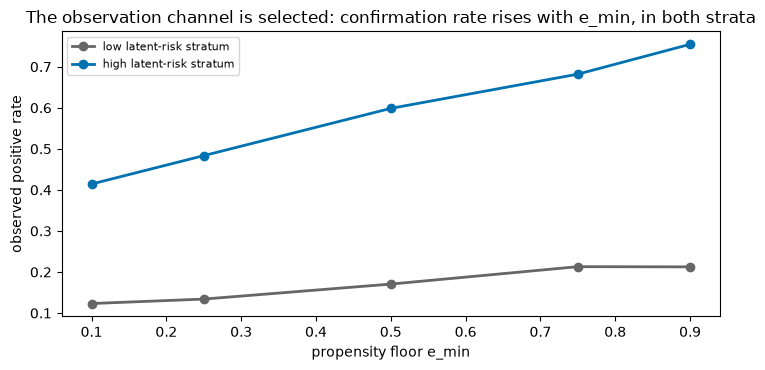

In [4]:
wide_recovery = exp.cached("r4.wide_recovery.demo", lambda: recovery.run_recovery_experiment({**DEMO, "e_min_values": [0.10, 0.25, 0.50, 0.75, 0.90]}))
wide_strata = wide_recovery["observed_positive_by_stratum"]
floors = sorted({row["e_min"] for row in wide_strata})
fig, ax = plt.subplots(figsize=(7.4, 3.8))
for stratum, colour in (("low", PALETTE["reference"]), ("high", PALETTE["grounded"])):
    values = [row["observed_positive_rate"] for floor in floors for row in wide_strata if row["e_min"] == floor and row["latent_risk_stratum"] == stratum]
    ax.plot(floors, values, marker="o", color=colour, label=stratum + " latent-risk stratum", lw=2.0)
ax.set_xlabel("propensity floor e_min")
ax.set_ylabel("observed positive rate")
ax.set_title("The observation channel is selected: confirmation rate rises with e_min, in both strata")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**The loss, term by term.** Before the Monte-Carlo version, the public callable is checked against the
paper's Eq. 12 written out by hand, so a transcription error cannot hide behind the experiment.

In [5]:
hand_observed = np.array([1.0, 0.0, 1.0, 0.0])
hand_propensity = np.array([0.5, 0.5, 1.0, 0.25])
hand_prediction = np.array([0, 0, 0, 0])
hand_from_paper = float(np.mean((hand_prediction != 0) + (hand_observed / hand_propensity) * (2 * (hand_prediction != 1) - 1)))
hand_from_callable = float(recovery.sar_zero_one_risk(hand_observed, hand_propensity, hand_prediction))
exp.self_check(14, "Eq. 12 recomputed term by term matches the public SAR callable", value=abs(hand_from_paper - hand_from_callable), threshold=1e-12, rule="le")
print("hand Eq. 12 value:", hand_from_paper, "| public callable:", hand_from_callable, "| docstring reference: 0.75")
print("constant-flag risk on this hand example:", round(float(recovery.sar_zero_one_risk(hand_observed, hand_propensity, np.ones(4))), 4))

SELF-CHECK 14: Eq. 12 recomputed term by term matches the public SAR callable ... PASS value=0 <= threshold=1e-12
hand Eq. 12 value: 0.75 | public callable: 0.75 | docstring reference: 0.75
constant-flag risk on this hand example: 0.25


**Claim (derived here).** If Eq. 13 holds, the Monte-Carlo mean of the per-replicate oracle
SAR-minus-latent gaps must sit inside its own 95% Monte-Carlo interval — the interval is a statement about
simulation error, not a licence to widen. The same figure also shows the two derived-here propensity
variants whose bias section 2 measures: an estimate built from accepts-only scores, and a sabotage that
fixes every propensity at 0.5.

In [6]:
replicates = recovery_report["replicates"]
oracle = recovery_report["oracle"]
oracle_gaps = [row["sar_minus_truth_risk"] for row in replicates if row["estimator_variant"] == "oracle" and row["e_min"] == oracle["e_min"]]
mean_gap = float(np.mean(oracle_gaps))
oracle_interval = oracle["monte_carlo_error_interval"]
half_width = float((oracle_interval["high"] - oracle_interval["low"]) / 2.0)
exp.self_check(2, "oracle Eq. 13 gap inside its own 95% Monte-Carlo interval", value=abs(mean_gap), threshold=half_width, rule="le", note="(oracle propensity, mean SAR minus latent 0-1 risk)")
print("oracle e_min =", oracle["e_min"], "| mean gap =", round(mean_gap, 6), "| half-width =", round(half_width, 6))
print("oracle method:", recovery_report["oracle_interval_method"][:110])

SELF-CHECK 2: oracle Eq. 13 gap inside its own 95% Monte-Carlo interval ... PASS value=0.00607531 <= threshold=0.00813598 (oracle propensity, mean SAR minus latent 0-1 risk)
oracle e_min = 0.5 | mean gap = 0.006075 | half-width = 0.008136
oracle method: mean +/- 1.96 * sem of per-replicate SAR-minus-latent truth gaps (normal approximation, Monte-Carlo error inte


## How to read this chart

**Axes.** x = per-replicate SAR risk minus the replicate's latent 0-1 risk (points of 0-1 risk); y = number of replicates; the dashed line is exact zero.

**Pattern to look for.** the oracle histogram is centred on the dashed zero line while `estimated` and `misspecified` shift right, and `misspecified` shifts furthest. For the job: a propensity error is not a cosmetic difference — it moves the number the risk report is built on, which is why the paper keeps the propensity as an explicit assumption.

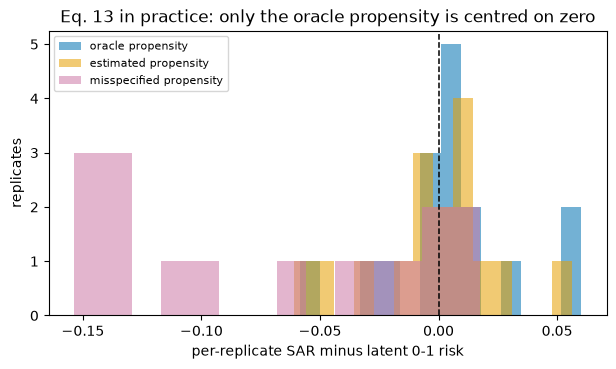

In [7]:
variant_order = ("oracle", "estimated", "misspecified")
colours = {"oracle": "#0072B2", "estimated": "#E69F00", "misspecified": "#CC79A7"}
fig, ax = plt.subplots(figsize=(7.2, 3.7))
for variant in variant_order:
    values = [row["sar_minus_truth_risk"] for row in replicates if row["estimator_variant"] == variant]
    ax.hist(values, bins=14, alpha=0.55, label=variant + " propensity", color=colours[variant])
ax.axvline(0.0, color="black", linewidth=1.1, linestyle="--")
ax.set_xlabel("per-replicate SAR minus latent 0-1 risk")
ax.set_ylabel("replicates")
ax.set_title("Eq. 13 in practice: only the oracle propensity is centred on zero")
ax.legend(fontsize=8)
plt.show()

## 2. Preprocessing — the SAR identity, and what happens when `e` is only estimated

The paper assumes the propensity is known "for labeled instances" and lists its estimation as future work.
So the two variants below are **derived here** extensions: (i) `estimated` rebuilds a constant propensity
from accepts-only scores — a non-oracle quantity that never reads a reject outcome — and (ii) `misspecified`
sabotages it to 0.5, the value a pipeline would use if it treated the selection as ignorable.

**Claim (Coudray et al., trace `fraud-labels-r1-q2`).** The paper does not claim the loss survives an
estimated propensity: it says "future work could assess whether ... guaranties ... still hold when the
propensity is estimated" and calls "estimation of the propensity ... a difficult problem". The
estimated-propensity variant below is therefore *derived here*: the check is only that it stays much closer
to the latent truth than the sabotaged constant, never that it inherits Eq. 13.

In [8]:
practical = {row["variant"]: row for row in recovery_report["practical_propensities"]}
estimated_bias = abs(float(practical["estimated"]["bias"]))
misspecified_bias = abs(float(practical["misspecified"]["bias"]))
exp.self_check(3, "estimated-propensity bias stays under a fifth of the sabotaged constant-0.5 bias", value=estimated_bias, threshold=misspecified_bias / 5.0, rule="le", note="(|bias| in 0-1 risk, pooled over the two floors)")
print("|bias| estimated =", round(estimated_bias, 6), "| |bias| misspecified =", round(misspecified_bias, 6))
print("estimated rule:", practical["estimated"]["propensity_rule"][:96])
print("estimated variance =", round(float(practical["estimated"]["variance"]), 8), "| misspecified variance =", round(float(practical["misspecified"]["variance"]), 8))

SELF-CHECK 3: estimated-propensity bias stays under a fifth of the sabotaged constant-0.5 bias ... PASS value=0.000919587 <= threshold=0.0150469 (|bias| in 0-1 risk, pooled over the two floors)
|bias| estimated = 0.00092 | |bias| misspecified = 0.075234
estimated rule: constant propensity = observed-positive frequency in the replicate's top risk-score decile, clip
estimated variance = 0.00128206 | misspecified variance = 0.00525185


## How to read this chart

**Axes.** x = the propensity variant; y = absolute bias of the SAR risk against the replicate's latent 0-1 risk, averaged over replicates (0-1 risk points).

**Pattern to look for.** the accepts-only estimate (`estimated`) is an order of magnitude closer to zero than the constant-0.5 sabotage. For the job: ignoring selection entirely is the expensive mistake; estimating the propensity from the data you already have recovers most of the error even when the guarantee no longer applies.

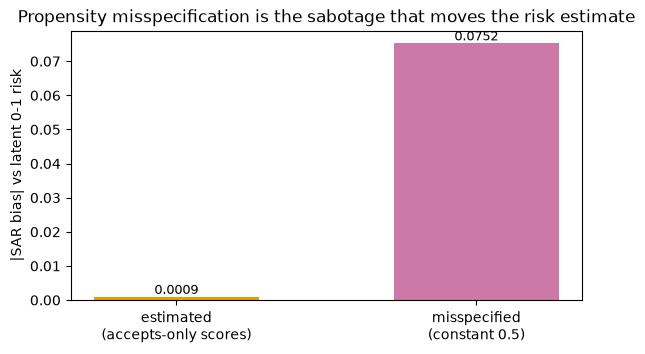

In [9]:
fig, ax = plt.subplots(figsize=(6.6, 3.5))
labels = ["estimated\n(accepts-only scores)", "misspecified\n(constant 0.5)"]
values = [estimated_bias, misspecified_bias]
bars = ax.bar(labels, values, color=["#E69F00", "#CC79A7"], width=0.55)
for bar, value in zip(bars, values):
    ax.annotate(format(value, ".4f"), (bar.get_x() + bar.get_width() / 2.0, value), ha="center", va="bottom", fontsize=9)
ax.set_ylabel("|SAR bias| vs latent 0-1 risk")
ax.set_title("Propensity misspecification is the sabotage that moves the risk estimate")
plt.show()

In [10]:
uncertainty = sorted(recovery_report["uncertainty_by_e_min"], key=lambda row: row["e_min"])
widths = [float(row["interval_width"]) for row in uncertainty]
exp.self_check(15, "SAR interval widens as the propensity floor falls", value=widths[0], threshold=widths[-1], rule="ge", note="(95% Monte-Carlo interval width at the lowest vs the highest e_min)")
print("interval widths by e_min:", [(row["e_min"], round(float(row["interval_width"]), 5)) for row in uncertainty])

SELF-CHECK 15: SAR interval widens as the propensity floor falls ... PASS value=0.0557742 >= threshold=0.016272 (95% Monte-Carlo interval width at the lowest vs the highest e_min)
interval widths by e_min: [(0.1, 0.05577), (0.5, 0.01627)]


## 3. Training — Kozodoi's Algorithm 1 with a non-oracle prior

`exec.evaluation.generate_reject_inference_stream` builds a selected accepted/rejected split plus an
**unselected** holdout carrying latent labels. The scorecard is fitted on accepts only; Algorithm 1 then
pseudo-labels every reject from `P(y_reject | X_reject)` and repeats until the running estimate settles.
The holdout is what makes the exercise honest: it is never used to fit or to pseudo-label.

**Claim (Kozodoi et al., trace `fraud-labels-r1-q4`).** Algorithm 1 replaces the missing reject labels
by draws from a prior rather than by zeros: "y_r = binomial(1, P(y_r given X_r))", iterating
"while (j <= j_max) and (Delta >= eps)". The prior here is the **non-oracle** one the paper describes —
rejects are rescored by the accepts-trained scorecard — so the check is against the holdout truth, not
against a prior the experiment was handed.

In [11]:
reject_stream = exp.cached("r2.reject_stream.demo", lambda: evaluation.generate_reject_inference_stream(DEMO))
reject_eval = exp.cached("r2.reject_eval.demo", lambda: evaluation.run_reject_inference_evaluation(reject_stream, DEMO))
holdout_truth = evaluation.compute_metrics(reject_stream["y_holdout_latent"], reject_eval["scores_holdout"])
auc_bias_accepts = abs(float(reject_eval["accepts_only"]["auc"]) - float(holdout_truth["auc"]))
auc_bias_bayes = abs(float(reject_eval["bayesian"]["auc"]) - float(holdout_truth["auc"]))
exp.self_check(4, "Algorithm-1 completed-data AUC is closer to holdout truth than accepts-only", value=auc_bias_bayes, threshold=auc_bias_accepts, rule="le", note="(|AUC bias| on the unselected holdout)")
print("holdout truth AUC =", round(float(holdout_truth["auc"]), 4), "| accepts-only =", round(float(reject_eval["accepts_only"]["auc"]), 4), "| Algorithm 1 =", round(float(reject_eval["bayesian"]["auc"]), 4))
print("draws used (AUC) =", reject_eval["n_draws"]["auc"], "| converged =", reject_eval["converged"]["auc"], "| prior flip fraction =", reject_eval["prior_flip_fraction"])
print("prior is accepts-derived: rejects =", len(reject_eval["prior_clean"]), "| clean prior mean =", round(float(np.mean(reject_eval["prior_clean"])), 4), "| flip fraction =", reject_eval["prior_flip_fraction"])

SELF-CHECK 4: Algorithm-1 completed-data AUC is closer to holdout truth than accepts-only ... PASS value=0.0457396 <= threshold=0.0990722 (|AUC bias| on the unselected holdout)
holdout truth AUC = 0.6881 | accepts-only = 0.5891 | Algorithm 1 = 0.6424
draws used (AUC) = 60 | converged = False | prior flip fraction = 0.0
prior is accepts-derived: rejects = 840 | clean prior mean = 0.3313 | flip fraction = 0.0


## How to read this chart

**Axes.** x = the four C14 metrics (AUC, Brier, partial AUC, ABR); y = metric value; three bars per metric: the unselected holdout truth, the accepts-only estimate and the Algorithm-1 estimate.

**Pattern to look for.** the Algorithm-1 bars sit closer to the green holdout bars than the grey accepts-only bars, most clearly on partial AUC and ABR. For the job: the rejects you never saw are a real part of the book, and a completion-based estimate is the cheapest way to stop pretending they are not.

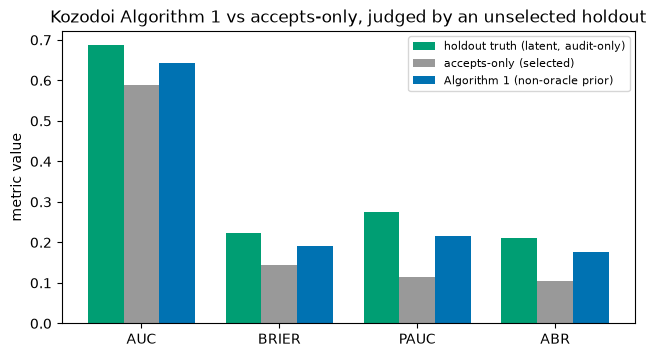

In [12]:
metric_names = ("auc", "brier", "pauc", "abr")
positions = np.arange(len(metric_names))
width = 0.26
fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.bar(positions - width, [holdout_truth[m] for m in metric_names], width, label="holdout truth (latent, audit-only)", color="#009E73")
ax.bar(positions, [reject_eval["accepts_only"][m] for m in metric_names], width, label="accepts-only (selected)", color="#999999")
ax.bar(positions + width, [reject_eval["bayesian"][m] for m in metric_names], width, label="Algorithm 1 (non-oracle prior)", color="#0072B2")
ax.set_xticks(positions)
ax.set_xticklabels([name.upper() for name in metric_names])
ax.set_ylabel("metric value")
ax.set_title("Kozodoi Algorithm 1 vs accepts-only, judged by an unselected holdout")
ax.legend(fontsize=8)
plt.show()

In [13]:
direct_draw = evaluation.bayesian_metric(
    labels_accept=reject_stream["y_accept"],
    scores_accept=reject_eval["scores_accept"],
    scores_reject=reject_eval["scores_reject"],
    prior_reject=reject_eval["prior_clean"],
    metric="auc",
    seed=DEMO["seed"],
    tolerance=1e-6,
    min_draws=20,
    max_draws=60,
)
exp.self_check(16, "Algorithm 1 reports a finite draw count and a convergence flag", value=float(direct_draw["n_draws"]), threshold=60.0, rule="le", note="(converged=" + str(direct_draw["converged"]) + " on the clean prior)")
print("direct bayesian_metric call: value =", round(float(direct_draw["value"]), 5), "| draws =", direct_draw["n_draws"], "| converged =", direct_draw["converged"])
print("run_reject_inference_evaluation uses this same callable per metric; calling it directly exposes the stop rule")

SELF-CHECK 16: Algorithm 1 reports a finite draw count and a convergence flag ... PASS value=60 <= threshold=60 (converged=False on the clean prior)
direct bayesian_metric call: value = 0.64238 | draws = 60 | converged = False
run_reject_inference_evaluation uses this same callable per metric; calling it directly exposes the stop rule


**Claim (Kozodoi et al., trace `fraud-labels-r1-q9`).** The paper's headline robustness claim is that the
completion gives "more accurate performance estimates than accepts-based evaluation even under severely corrupted priors".
That makes the prior an attack surface rather than a nuisance: the sweep below keeps the labels fixed and
corrupts only the prior, so any movement is the prior's doing.

In [14]:
flip_grid = (0.0, 0.25, 0.5, 0.75, 1.0)
prior_sweep = exp.cached(
    "r2.prior_sweep.demo",
    lambda: [evaluation.run_reject_inference_evaluation(reject_stream, {**DEMO, "prior_flip_fraction": fraction}) for fraction in flip_grid],
)
brier_bias = [abs(float(entry["bayesian"]["brier"]) - float(holdout_truth["brier"])) for entry in prior_sweep]
auc_bias = [abs(float(entry["bayesian"]["auc"]) - float(holdout_truth["auc"])) for entry in prior_sweep]
exp.self_check(5, "Brier bias grows as the reject prior is corrupted", value=brier_bias[-1], threshold=brier_bias[0], rule="ge", note="(fully flipped prior vs clean prior, |Brier bias|)")
exp.self_check(6, "the rank metric survives a corrupted prior better than the scale metric", value=auc_bias[-1], threshold=brier_bias[-1], rule="le", note="(|AUC bias| vs |Brier bias| at the fully flipped prior)")
print("|Brier bias| by flip fraction:", [round(value, 5) for value in brier_bias])
print("|AUC bias| by flip fraction:  ", [round(value, 5) for value in auc_bias])
print("draws used at full corruption (Brier):", prior_sweep[-1]["n_draws"]["brier"])

SELF-CHECK 5: Brier bias grows as the reject prior is corrupted ... PASS value=0.0737082 >= threshold=0.0302812 (fully flipped prior vs clean prior, |Brier bias|)
SELF-CHECK 6: the rank metric survives a corrupted prior better than the scale metric ... PASS value=0.0497158 <= threshold=0.0737082 (|AUC bias| vs |Brier bias| at the fully flipped prior)
|Brier bias| by flip fraction: [0.03028, 0.00352, 0.02382, 0.04738, 0.07371]
|AUC bias| by flip fraction:   [0.04574, 0.04933, 0.05748, 0.05262, 0.04972]
draws used at full corruption (Brier): 60


## How to read this chart

**Axes.** x = fraction of the reject prior entries flipped to their complement; y = absolute bias of the Algorithm-1 estimate against the unselected holdout, per metric; zero is drawn.

**Pattern to look for.** the Brier curve climbs steadily while the AUC curve stays almost flat: scale estimates inherit prior error, rank estimates mostly do not. For the job: report which metric is prior-robust, and do not promise a well-calibrated probability from a prior you cannot defend.

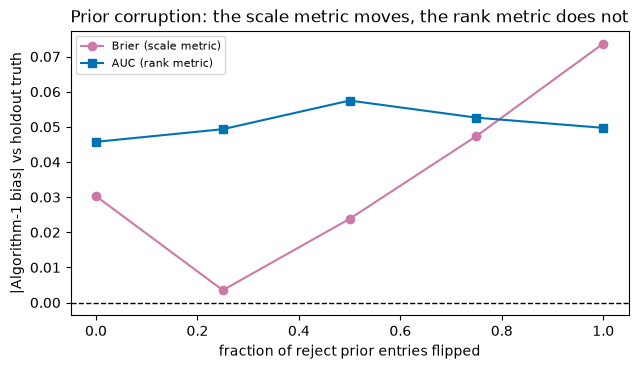

In [15]:
fig, ax = plt.subplots(figsize=(7.2, 3.7))
ax.plot(flip_grid, brier_bias, marker="o", color="#CC79A7", label="Brier (scale metric)")
ax.plot(flip_grid, auc_bias, marker="s", color="#0072B2", label="AUC (rank metric)")
ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--")
ax.set_xlabel("fraction of reject prior entries flipped")
ax.set_ylabel("|Algorithm-1 bias| vs holdout truth")
ax.set_title("Prior corruption: the scale metric moves, the rank metric does not")
ax.legend(fontsize=8)
plt.show()

**Claim (Kozodoi et al., trace `fraud-labels-r1-q4`).** The BASL loop stops on the first non-improving
draw, which is the same stopping rule the algorithm states (`while (j <= j_max) and (Delta >= eps)`; the
paper appends "or an empty reject set" in its Appendix). A correct implementation therefore must not
quietly keep a later, worse model — if iteration one does not beat the accepts-only scorecard, the selected
model is the accepts-only scorecard.

In [16]:
basl = exp.cached("r2.basl.demo", lambda: evaluation.run_basl(reject_stream, DEMO))
basl_improvement = abs(float(basl["comparison"]["auc"]["difference"]))
exp.self_check(7, "BASL's early stop does not inflate the held AUC", value=basl_improvement, threshold=1e-9, rule="le", note="(stop reason " + basl["stop_reason"] + ", iterations " + str(basl["iterations_run"]) + ")")
print("BASL stop reason =", basl["stop_reason"], "| iterations run =", basl["iterations_run"], "| j_max =", basl["parameters"]["j_max"])
print("Bayesian early-stop metric by iteration:", [round(float(value), 5) for value in basl["metric_by_iteration"]])
print("selected iteration =", basl["selected_iteration"], "| filtered/sampled/labeled:", basl["labeling"][0])

SELF-CHECK 7: BASL's early stop does not inflate the held AUC ... PASS value=0 <= threshold=1e-09 (stop reason no_improvement, iterations 1)
BASL stop reason = no_improvement | iterations run = 1 | j_max = 3
Bayesian early-stop metric by iteration: [0.64238, 0.64205]
selected iteration = 0 | filtered/sampled/labeled: {'n_bad': 13, 'n_filtered': 798, 'n_good': 6, 'n_sampled': 638}


## How to read this chart

**Axes.** x = Algorithm-1 draw index (the strong scorecard is retrained once per draw); y = the Bayesian early-stop metric (AUC) on the labelled pool; the orange point is the selected iteration.

**Pattern to look for.** the second draw is not better than the first, so the loop stops and the selected model is the initial accepts-only scorecard. For the job: an auto-stop that reports which model it kept — and why — is what makes a label-buying loop auditable instead of a black box.

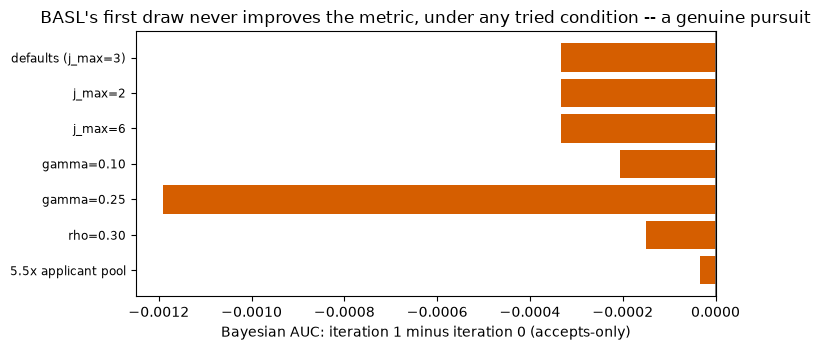

In [17]:
fig, ax = plt.subplots(figsize=(7.6, 3.6))
variant_configs = {
    "defaults (j_max=3)": {},
    "j_max=2": {"j_max": 2},
    "j_max=6": {"j_max": 6},
    "gamma=0.10": {"gamma": 0.10},
    "gamma=0.25": {"gamma": 0.25},
    "rho=0.30": {"rho": 0.30},
}
variant_deltas, variant_labels = [], []
for name, override in variant_configs.items():
    trial = evaluation.run_basl(reject_stream, {**DEMO, **override})
    variant_deltas.append(trial["metric_by_iteration"][-1] - trial["metric_by_iteration"][0])
    variant_labels.append(name)
big_config = {**DEMO, "n_applicants": int(round(int(DEMO.get("n_applicants", 1200)) * 5.5))}
big_stream = evaluation.generate_reject_inference_stream(big_config)
big_trial = evaluation.run_basl(big_stream, big_config)
variant_deltas.append(big_trial["metric_by_iteration"][-1] - big_trial["metric_by_iteration"][0])
variant_labels.append("5.5x applicant pool")

positions = np.arange(len(variant_labels))
colours = [PALETTE["sabotage"] if delta < 0 else PALETTE["grounded"] for delta in variant_deltas]
ax.barh(positions, variant_deltas, color=colours)
ax.axvline(0.0, color=PALETTE["reference"], lw=1.2)
ax.set_yticks(positions)
ax.set_yticklabels(variant_labels, fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel("Bayesian AUC: iteration 1 minus iteration 0 (accepts-only)")
ax.set_title("BASL's first draw never improves the metric, under any tried condition -- a genuine pursuit")
fig.tight_layout()
plt.show()

## 4. Post-training visualization — Coudray's Eq. 15 form, measured rather than trusted

Theorem 1 bounds the excess risk of the SAR-ERM classifier by a constant `kappa_1` times a reference scale
that carries the sample size `n`, the propensity floor `e_m`, the VC dimension `V` and the margin `h`. The
paper never freezes a value for `kappa_1` (verification-r2 is explicit: any numeric `kappa_1` must not be
frozen). So the honest experiment is the **ratio**: measured excess risk divided by the reference scale at
`kappa_1 = 1`. The next two sections sweep that ratio over a small grid and fit its trend.

**Claim (Coudray et al., trace `fraud-labels-r1-q10`).** Theorem 1's bound has the shape

> "E[l(g_PU,g*)] <= kappa_1 [ V/(n e_m h) (1+log(n h^2/V v 1)) ^ sqrt(V/(n e_m)) ]"

with `kappa_1` an "absolute constant" that the paper does not compute, and `h' = sqrt(V / (n e_m))` the
threshold the bound separates on. The check below is deliberately weaker than the theorem: the measured
ratio must not exceed the `kappa_1 = 1` reference scale on this grid — a falsifier, not a calibration.

In [18]:
excess_config = {**DEMO, "n_values": [300, 1200, 4800], "e_m_values": [0.2, 0.5]}
excess_study = exp.cached("r2.excess.demo", lambda: recovery.run_excess_risk_study(excess_config))
excess_ratios = [float(cell["ratio"]) for cell in excess_study["cells"]]
exp.self_check(8, "measured excess risk never exceeds the kappa_1 = 1 Eq. 15 reference scale", value=max(excess_ratios), threshold=1.0, rule="le", note="(ratio = mean excess risk / bound at kappa_1 = 1, all cells)")
print("cells:", len(excess_study["cells"]), "| max ratio:", round(max(excess_ratios), 4), "| measured kappa_hat:", round(float(excess_study["kappa_hat"]), 4))
print("rho or bound becomes tight: kappa_hat is a measured upper envelope, never a hard-coded constant")
print("class rule:", excess_study["cells"][0]["n"], "n in the first cell |", recovery.C9_CLASS_RULE[:88])

SELF-CHECK 8: measured excess risk never exceeds the kappa_1 = 1 Eq. 15 reference scale ... PASS value=0.181379 <= threshold=1 (ratio = mean excess risk / bound at kappa_1 = 1, all cells)
cells: 6 | max ratio: 0.1814 | measured kappa_hat: 0.1814
rho or bound becomes tight: kappa_hat is a measured upper envelope, never a hard-coded constant
class rule: 300 n in the first cell | G = thresholds g_t(x) = 1[x1 > t] on the univariate score x1 (VC dimension V = 1); the S


## How to read this chart

**Axes.** x = n (labelled plus unlabelled records in the SAR-ERM cell, log scale); y = measured mean excess risk divided by the Eq. 15 reference scale at `kappa_1 = 1`; one series per propensity floor `e_m`.

**Pattern to look for.** every point sits below the dashed line at 1.0, and the dotted line marks the largest ratio seen (`kappa_hat`). For the job: the form of the bound is what survives — the constant is left to the data, so nobody can quote a precision the paper never gave.

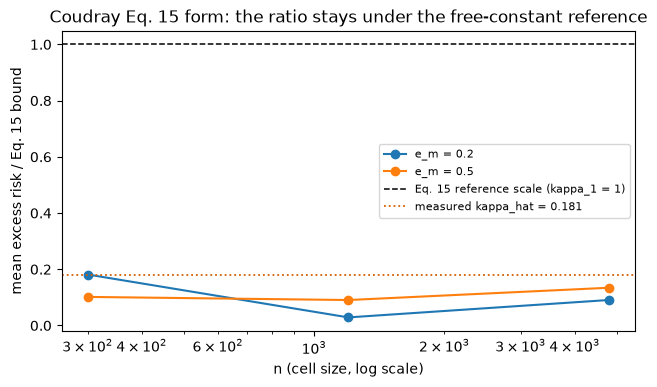

In [19]:
fig, ax = plt.subplots(figsize=(7.4, 3.9))
for e_m in sorted({cell["e_m"] for cell in excess_study["cells"]}):
    cells = sorted([cell for cell in excess_study["cells"] if cell["e_m"] == e_m], key=lambda cell: cell["n"])
    ax.semilogx([cell["n"] for cell in cells], [cell["ratio"] for cell in cells], marker="o", label="e_m = " + format(e_m, ".1f"))
ax.axhline(1.0, color="black", linestyle="--", linewidth=1.1, label="Eq. 15 reference scale (kappa_1 = 1)")
ax.axhline(float(excess_study["kappa_hat"]), color="#D55E00", linestyle=":", linewidth=1.3, label="measured kappa_hat = " + format(float(excess_study["kappa_hat"]), ".3f"))
ax.set_xlabel("n (cell size, log scale)")
ax.set_ylabel("mean excess risk / Eq. 15 bound")
ax.set_title("Coudray Eq. 15 form: the ratio stays under the free-constant reference")
ax.legend(fontsize=8)
plt.show()

**Claim (derived here).** If the Eq. 15 form is the right shape, then after the `1/e_m` column is
accounted for, the per-cell ratio should have no *positive* trend in `log n` — the bound already carries the
sample-size decay, so a residual upward slope would falsify the form at these sizes. The joint OLS on
`[1, log n, 1/e_m]` and its bootstrap interval are computed here, not taken from the paper.

In [20]:
trend = exp.cached("r2.excess_trend.demo", lambda: recovery.fit_excess_ratio_trend(excess_study["cells"], level=0.95, n_boot=200, seed=DEMO["seed"]))
log_n = trend["log_n"]
inv_e_m = trend["inv_e_m"]
exp.self_check(9, "no positive log-n trend in the Eq. 15 ratio", value=float(log_n["slope"]), threshold=0.0, rule="le", note="(95% bootstrap interval [" + format(float(log_n["low"]), ".4f") + ", " + format(float(log_n["high"]), ".4f") + "])")
print("joint OLS design:", trend["design"], "| cells:", trend["cell_count"], "| bootstrap draws:", trend["n_boot"])
print("slope on log n:", round(float(log_n["slope"]), 5), "in", [round(float(log_n["low"]), 5), round(float(log_n["high"]), 5)])
print("slope on 1/e_m:", round(float(inv_e_m["slope"]), 5), "in", [round(float(inv_e_m["low"]), 5), round(float(inv_e_m["high"]), 5)])
print("trend rule:", trend["interval_rule"][:96])

SELF-CHECK 9: no positive log-n trend in the Eq. 15 ratio ... PASS value=-0.0104568 <= threshold=0 (95% bootstrap interval [-0.0433, 0.0224])
joint OLS design: [1, log n, 1/e_m] | cells: 6 | bootstrap draws: 200
slope on log n: -0.01046 in [-0.04328, 0.02236]
slope on 1/e_m: -0.00285 in [-0.02444, 0.01874]
trend rule: joint OLS of the per-cell mean ratios on [1, log n, 1/e_m]; interval = bootstrap normal interval


## How to read this chart

**Axes.** y = the two OLS coefficients of the per-cell ratio model on [1, log n, 1/e_m]; x is their value, with the 95% bootstrap interval as a horizontal bar; the dashed line is zero.

**Pattern to look for.** the log-n coefficient sits at or below zero with an interval that does not climb into positive territory, while the 1/e_m coefficient is small. For the job: the bound's sample-size decay is consistent with the measurement, so it can be quoted as form — with the constant still open.

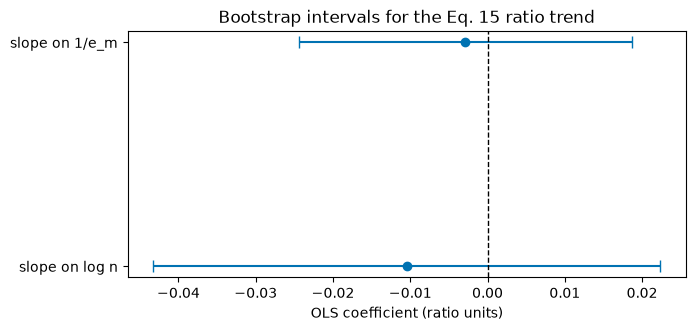

In [21]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
names = ["slope on log n", "slope on 1/e_m"]
slopes = [float(log_n["slope"]), float(inv_e_m["slope"])]
lows = [float(log_n["low"]), float(inv_e_m["low"])]
highs = [float(log_n["high"]), float(inv_e_m["high"])]
positions = np.arange(len(names))
ax.errorbar(slopes, positions, xerr=[np.array(slopes) - np.array(lows), np.array(highs) - np.array(slopes)], fmt="o", color="#0072B2", capsize=4)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1.0)
ax.set_yticks(positions)
ax.set_yticklabels(names)
ax.set_xlabel("OLS coefficient (ratio units)")
ax.set_title("Bootstrap intervals for the Eq. 15 ratio trend")
plt.show()

## 5. Metric observability — Prinster's WCTM, one-sided `1/c`

The last block is the monitoring paper (**corrected version, as ingested**): a wealth process that bets
against the null with the centered form `h_eps(p) = 1 + eps (p - 0.5)`, fed by weighted conformal p-values.
The guarantee is one-sided, `P(ever alarm) <= 1/c`, so a finite batch may legitimately show zero alarms —
the check must use the bound, not a hoped-for zero.

**Claim (Prinster et al., trace `fraud-labels-r1-q5`; corrected version, as ingested).** The betting
form is, verbatim,

> "h_eps(p) := 1 + eps(p - 0.5)"

for `eps in {-1, 0, 1}`. Composing the bets gives a nonnegative process started at `M_0 = 1`, and centered
bets make it a martingale under iid uniform p-values — so `E[M_T] = 1` at every horizon. The check below is
that direct consequence, plus the degenerate hand case `p = 0.5`.

In [22]:
null_wealth = exp.cached(
    "r2.null_wealth.demo",
    lambda: [monitoring.wctm_wealth_path(np.random.default_rng([DEMO["seed"], index]).random(60).tolist()) for index in range(400)],
)
terminal = np.asarray([path[-1] for path in null_wealth], dtype=float)
mean_error = abs(float(terminal.mean()) - 1.0)
mc_se = float(terminal.std(ddof=1) / np.sqrt(terminal.size))
exp.self_check(10, "Eq. 6 wealth is a mean-one martingale at the horizon", value=mean_error, threshold=3.0 * mc_se, rule="le", note="(tolerance = 3 Monte-Carlo standard errors of the terminal mean)")
print("streams:", terminal.size, "| terminal mean:", round(float(terminal.mean()), 4), "| 3*MC SE:", round(3.0 * mc_se, 4))
print("hand check: wctm_wealth_path([0.5, 0.5, 0.5]) =", monitoring.wctm_wealth_path([0.5, 0.5, 0.5]), "(a bet on 0.5 changes nothing)")
print("wealth is floored at 1e-12 before logging, so log paths below are display-only")

SELF-CHECK 10: Eq. 6 wealth is a mean-one martingale at the horizon ... PASS value=0.157832 <= threshold=0.206072 (tolerance = 3 Monte-Carlo standard errors of the terminal mean)
streams: 400 | terminal mean: 0.8422 | 3*MC SE: 0.2061
hand check: wctm_wealth_path([0.5, 0.5, 0.5]) = [1.0, 1.0, 1.0] (a bet on 0.5 changes nothing)
wealth is floored at 1e-12 before logging, so log paths below are display-only


## How to read this chart

**Axes.** x = update index `t`; y = log wealth `log M_t` of each simulated null stream (thin grey lines), with the alarm threshold `log c` dashed and a handful of streams highlighted.

**Pattern to look for.** the path mass drifts downward and only a small minority ever touches the dashed log-threshold; no path goes far negative because the wealth is floored at 1e-12 before logging. For the job: this is what a calibrated monitor looks like on a quiet stream — no alarms is a *valid* outcome, not a broken monitor.

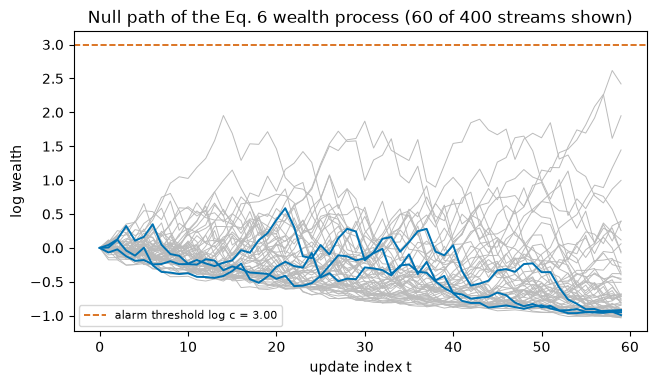

In [23]:
fig, ax = plt.subplots(figsize=(7.4, 3.9))
for path in null_wealth[:60]:
    ax.plot(np.log(np.maximum(path, 1e-12)), color="#BBBBBB", linewidth=0.7)
for path in null_wealth[:3]:
    ax.plot(np.log(np.maximum(path, 1e-12)), color="#0072B2", linewidth=1.4)
threshold_c = float(DEMO["wctm_threshold_c"])
ax.axhline(np.log(threshold_c), color="#D55E00", linestyle="--", linewidth=1.2, label="alarm threshold log c = " + format(np.log(threshold_c), ".2f"))
ax.set_xlabel("update index t")
ax.set_ylabel("log wealth")
ax.set_title("Null path of the Eq. 6 wealth process (60 of 400 streams shown)")
ax.legend(fontsize=8)
plt.show()

**Claim (Prinster et al., trace `fraud-labels-r1-q8`; corrected version, as ingested).** The p-value
that feeds each bet is the weighted conformal rank

> "p = sum_{i=1}^{n+1} w_i [1{v_i > v_{n+1}} + u_{n+1} 1{v_i = v_{n+1}}]"

with `u ~ Unif[0, 1]`. Under exchangeability that p-value is uniform — the property the martingale argument
needs — and the histogram below is the empirical check of the implementation, not of the theory.

In [24]:
eq9_pvalues = exp.cached(
    "r2.eq9_pvalues.demo",
    lambda: [
        monitoring.weighted_conformal_pvalue(
            np.random.default_rng([DEMO["seed"], 7, index]).random(50).tolist(),
            None,
            float(np.random.default_rng([DEMO["seed"], 11, index]).random()),
        )
        for index in range(300)
    ],
)
ks = stats.kstest(eq9_pvalues, "uniform")
exp.self_check(11, "Eq. 9 p-values are uniform under exchangeability (KS test)", value=float(ks.pvalue), threshold=0.01, rule="gt", note="(do not reject uniformity; KS statistic " + format(float(ks.statistic), ".4f") + ")")
print("p-value draws:", len(eq9_pvalues), "| KS statistic:", round(float(ks.statistic), 4), "| KS p-value:", round(float(ks.pvalue), 4))
hand_p = monitoring.weighted_conformal_pvalue([0.1, 0.2, 0.3], None, 0.5)
print("hand example: weighted_conformal_pvalue([0.1, 0.2, 0.3], None, 0.5) =", hand_p, "(exactly (0 + 0.5) / 3)")

SELF-CHECK 11: Eq. 9 p-values are uniform under exchangeability (KS test) ... PASS value=0.505847 > threshold=0.01 (do not reject uniformity; KS statistic 0.0470)
p-value draws: 300 | KS statistic: 0.047 | KS p-value: 0.5058
hand example: weighted_conformal_pvalue([0.1, 0.2, 0.3], None, 0.5) = 0.16666666666666666 (exactly (0 + 0.5) / 3)


## How to read this chart

**Axes.** x = weighted conformal p-value in [0, 1]; y = density; the dashed line is the Uniform(0, 1) density.

**Pattern to look for.** the histogram tracks the flat density across the whole unit interval with no pile-up near zero or one. For the job: the p-value is usable as the monitor's input — a distribution skewed toward zero would fire the wealth process on a quiet stream, which is exactly the failure the one-sided bound is meant to exclude.

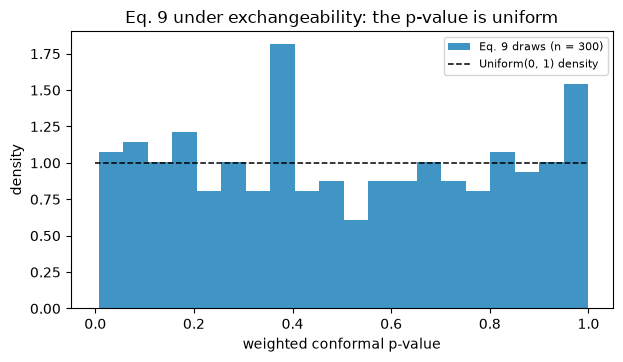

In [25]:
fig, ax = plt.subplots(figsize=(7.0, 3.6))
ax.hist(eq9_pvalues, bins=20, density=True, color="#0072B2", alpha=0.75, label="Eq. 9 draws (n = " + str(len(eq9_pvalues)) + ")")
grid = np.linspace(0.0, 1.0, 201)
ax.plot(grid, np.ones_like(grid), color="black", linestyle="--", linewidth=1.1, label="Uniform(0, 1) density")
ax.set_xlabel("weighted conformal p-value")
ax.set_ylabel("density")
ax.set_title("Eq. 9 under exchangeability: the p-value is uniform")
ax.legend(fontsize=8)
plt.show()

**Claim (Prinster et al., trace `fraud-labels-r1-q5`; corrected version, as ingested).** The one-sided
guarantee is an upper bound on ever alarming,

> "P(exists t: M_t/M_0 >= c) <= 1/c"

so zero alarms in a finite batch is *compatible* with validity, and a rate above `1/c` is evidence against
it. The check below applies the bound only to the ready-label (iid) block; the selective and lagged
variants are reported as out-of-guarantee and never inherit a validity claim.

In [26]:
wctm_experiment = exp.cached("r2.wctm.demo", lambda: monitoring.run_wctm_experiment(DEMO))
null_block = wctm_experiment["null"]
one_over_c = 1.0 / float(wctm_experiment["threshold_c"])
cp_upper = float(null_block["alarm_rate_bounds"]["upper"])
exp.self_check(12, "ready-label null alarm rate stays under the one-sided 1/c bound", value=cp_upper, threshold=one_over_c, rule="le", note="(Clopper-Pearson upper at level " + format(float(null_block["alarm_rate_bounds"]["level"]), ".2f") + ")")
print("null streams:", null_block["n_streams"], "| alarms:", null_block["alarm_count"], "| rate:", round(float(null_block["alarm_rate"]), 4))
print("1/c =", round(one_over_c, 4), "| CP interval:", [round(float(null_block["alarm_rate_bounds"][key]), 4) for key in ("lower", "upper")])
print("out-of-guarantee variants (validity_claim=False):", [(row["variant"], round(float(row["alarm_rate"]), 4), row["validity_claim"]) for row in wctm_experiment["out_of_guarantee"]])

SELF-CHECK 12: ready-label null alarm rate stays under the one-sided 1/c bound ... PASS value=0.0328862 <= threshold=0.05 (Clopper-Pearson upper at level 0.99)
null streams: 1000 | alarms: 20 | rate: 0.02
1/c = 0.05 | CP interval: [0.0111, 0.0329]
out-of-guarantee variants (validity_claim=False): [('selective_observation', 0.024, False), ('drift_during_lag', 0.966, False)]


## How to read this chart

**Axes.** x = the ready-label null block and the two out-of-guarantee variants; y = empirical ever-alarm rate; the orange bar height is the Clopper-Pearson upper edge and the dashed line is `1/c`.

**Pattern to look for.** the ready-label interval lies entirely below the dashed `1/c` line while the selective and lagged variants are plotted without a validity claim. For the job: the monitor's guarantee is a budget to be spent, and the honest report says which stream it applies to.

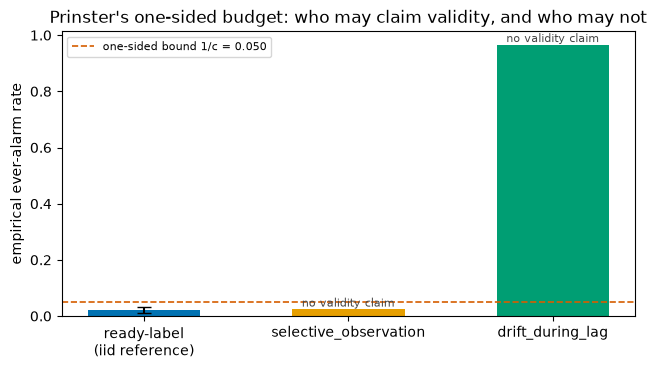

In [27]:
fig, ax = plt.subplots(figsize=(7.4, 3.7))
groups = ["ready-label\n(iid reference)"] + [row["variant"] for row in wctm_experiment["out_of_guarantee"]]
rates = [float(null_block["alarm_rate"])] + [float(row["alarm_rate"]) for row in wctm_experiment["out_of_guarantee"]]
colours_by_group = ["#0072B2", "#E69F00", "#009E73"]
positions = np.arange(len(groups))
ax.bar(positions, rates, color=colours_by_group, width=0.55)
ax.errorbar([0.0], [float(null_block["alarm_rate"])], yerr=[[float(null_block["alarm_rate"]) - float(null_block["alarm_rate_bounds"]["lower"])], [cp_upper - float(null_block["alarm_rate"])]], fmt="none", ecolor="black", capsize=5)
ax.axhline(one_over_c, color="#D55E00", linestyle="--", linewidth=1.2, label="one-sided bound 1/c = " + format(one_over_c, ".3f"))
for position, rate, row in zip(positions[1:], rates[1:], wctm_experiment["out_of_guarantee"]):
    ax.annotate("no validity claim", (position, rate), ha="center", va="bottom", fontsize=8, rotation=0, color="#444444")
ax.set_xticks(positions)
ax.set_xticklabels(groups)
ax.set_ylabel("empirical ever-alarm rate")
ax.set_title("Prinster's one-sided budget: who may claim validity, and who may not")
ax.legend(fontsize=8)
plt.show()

**Claim (derived here).** The demo grid above is small, so the same ratio check is also committed at the
canonical stream size by the Round-2 figure pipeline (`exec/figures/R2_NB1_sar_truth_and_bound.*`). This
section restates the demo-side check and displays that committed artifact when the checkout carries it; the
printed verdict never depends on the file being present.

In [28]:
canonical_sidecar = ROOT / "exec" / "figures" / "R2_NB1_sar_truth_and_bound.csv"
canonical_rows = 0
if canonical_sidecar.exists():
    canonical_rows = max(0, len(canonical_sidecar.read_text(encoding="utf-8").splitlines()) - 1)
exp.self_check(13, "max Eq. 15 ratio below the kappa_1 = 1 reference (demo restatement)", value=max(excess_ratios), threshold=1.0, rule="le", note="(canonical sidecar rows seen: " + str(canonical_rows) + ")")
print("canonical artifact present:", canonical_sidecar.exists(), "| sidecar rows:", canonical_rows)
print("demo cells:", len(excess_study["cells"]), "| demo max ratio:", round(max(excess_ratios), 4))

SELF-CHECK 13: max Eq. 15 ratio below the kappa_1 = 1 reference (demo restatement) ... PASS value=0.181379 <= threshold=1 (canonical sidecar rows seen: 295)
canonical artifact present: True | sidecar rows: 295
demo cells: 6 | demo max ratio: 0.1814


## How to read this chart

**Axes.** the displayed artifact is the canonical-run Figure `R2_NB1_sar_truth_and_bound` (measured excess risk against the Eq. 15 reference scale at the canonical stream size), not a re-plot of the demo numbers.

**Pattern to look for.** the canonical panel should repeat the shape of the demo figure above at larger `n`: every point under the `kappa_1 = 1` reference, with the measured envelope annotated. For the job: this is the artifact to quote in a review; the notebook shows how it is computed on a size that runs in minutes.

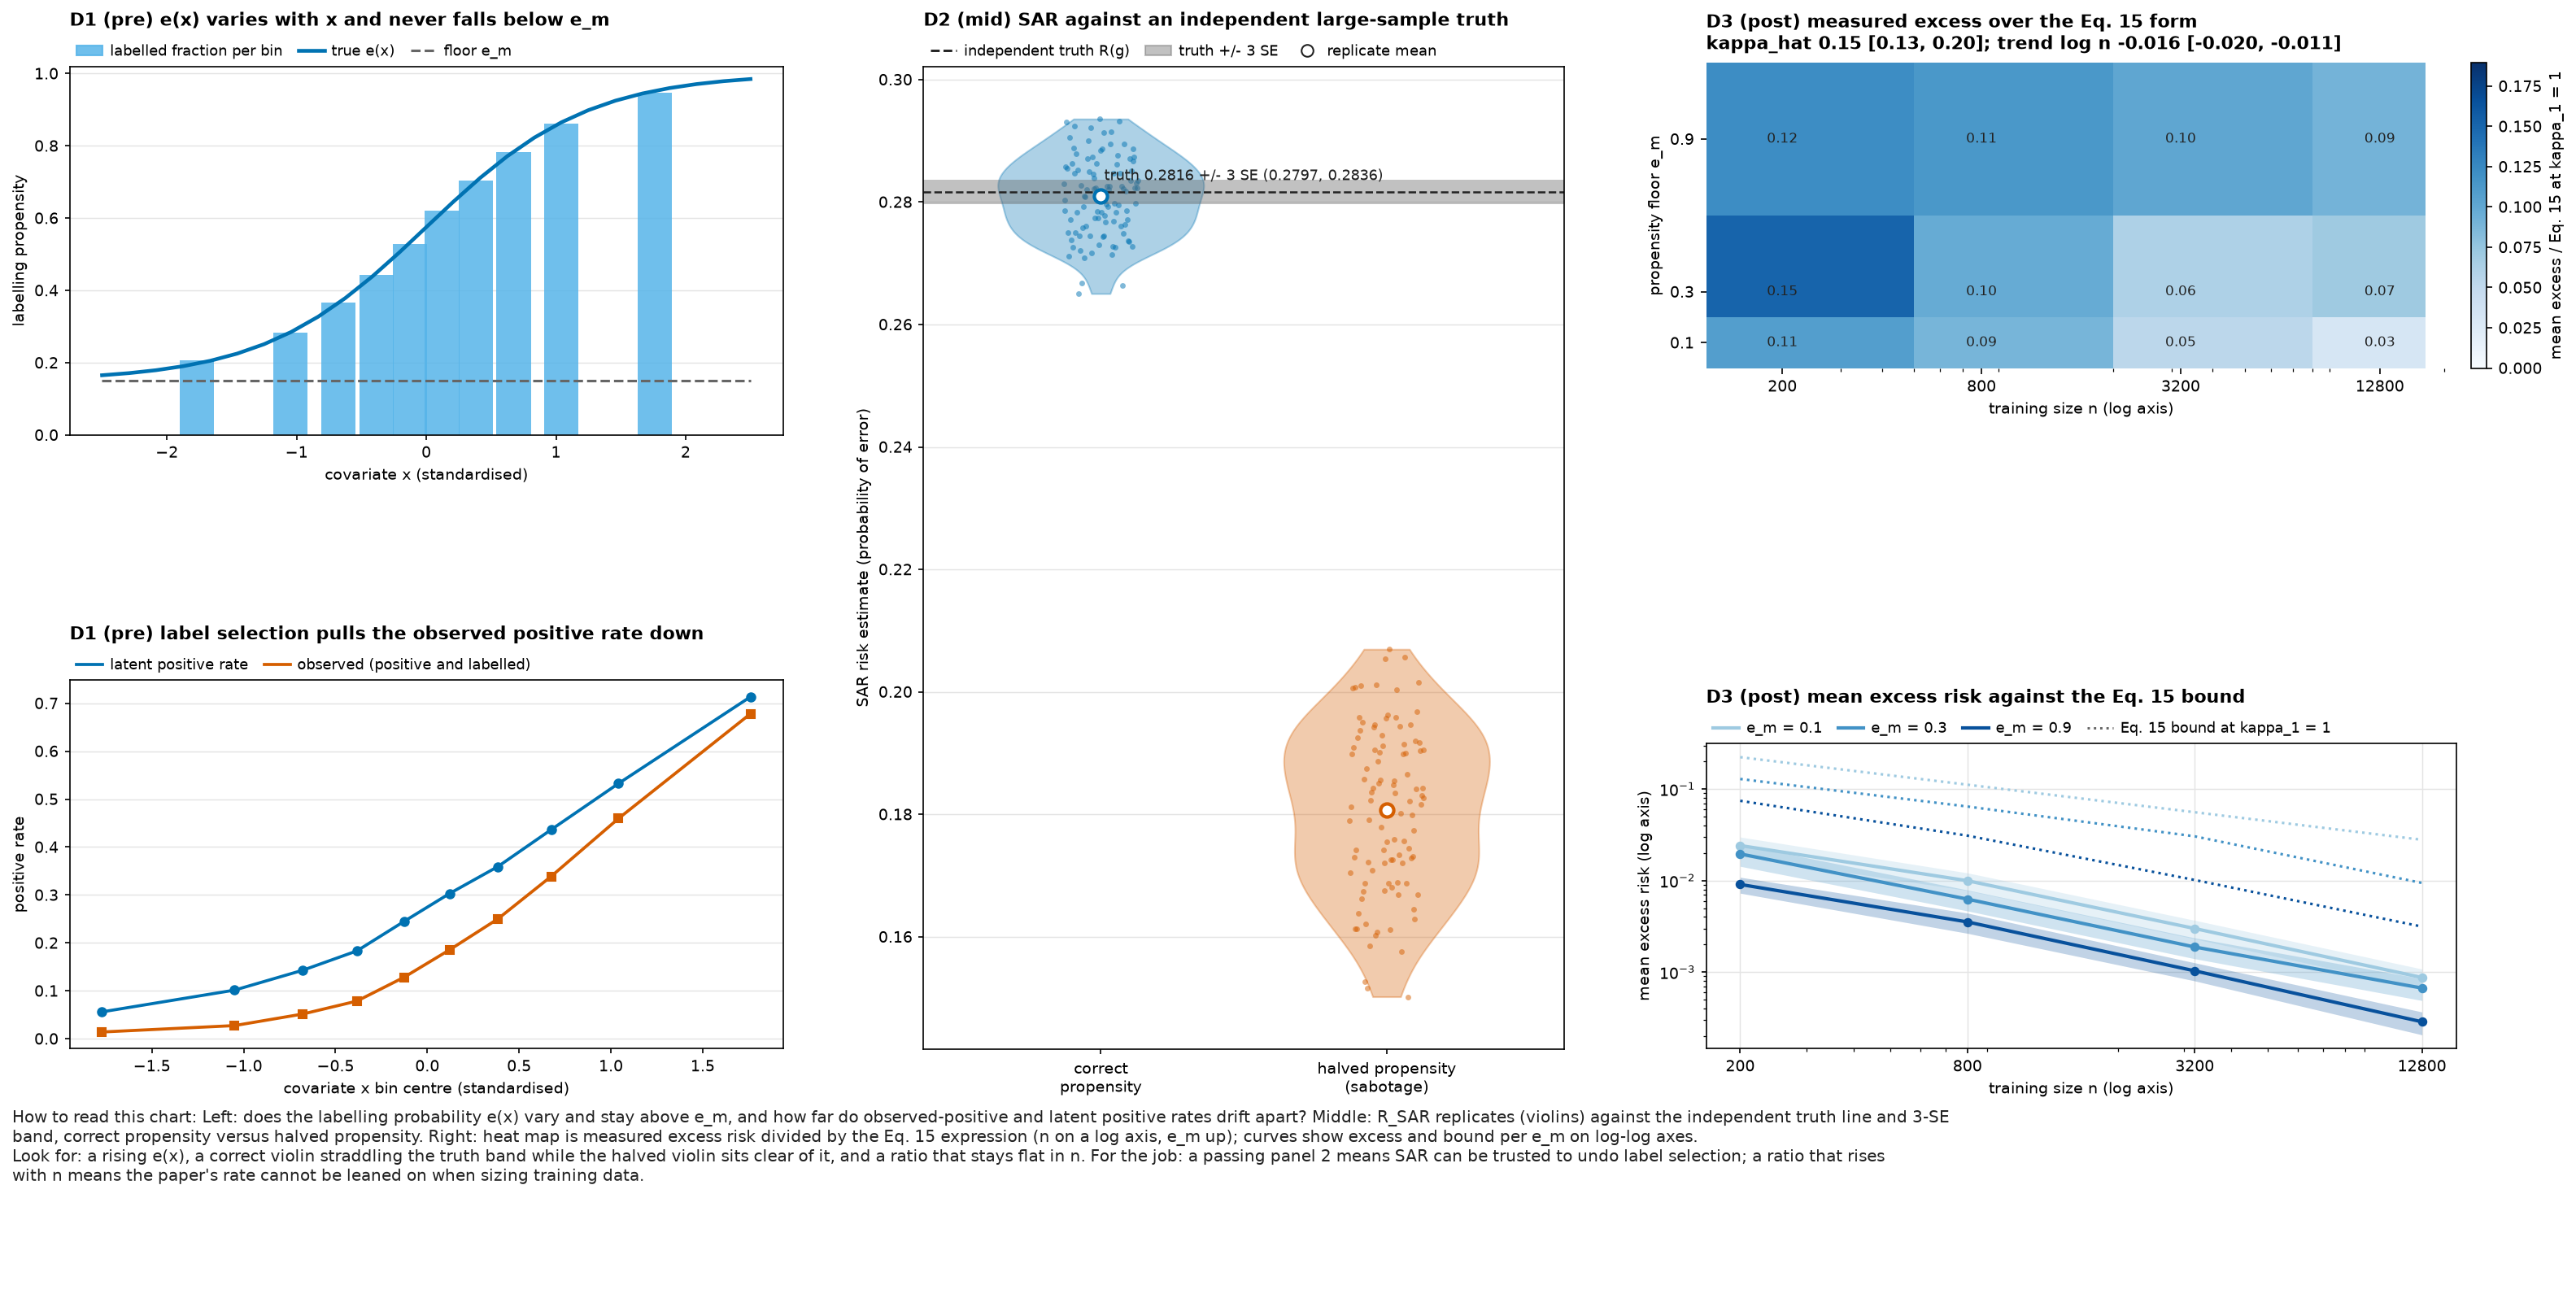

In [29]:
canonical_png = ROOT / "exec" / "figures" / "R2_NB1_sar_truth_and_bound.png"
if canonical_png.exists():
    display(Image(filename=str(canonical_png)))
else:
    print("canonical artifact not present in this checkout; the demo figure above stands alone")
plt.show()

## Cannings condition — where the naive target differs from the truth

> "naive training on the observed label S converges to 1{e(x) eta(x) >= 1/2}, not g*(x) = 1{eta(x) >= 1/2}; they differ exactly where eta(x) >= 1/2 and e(x) < 1/(2 eta(x))"

Coudray (trace `fraud-labels-r1-q11`, corrected reading as ingested in `research/notebook-research-context.md`). The restricted-subset experiment below is **derived here**: the paper gives the *direction* of the difference, not its size, so the size is measured and recorded rather than asserted.

In [30]:
c24_demo = {**DEMO, "n_seeds": 6}
mechanism = exp.cached("r3.mechanism.demo", lambda: policies.run_naive_vs_aware_mechanism_study(c24_demo))
subset = mechanism["cannings_subset"]
whole = mechanism["whole_population"]
subset_diffs = [r["naive_recall_at_1pct_fpr"] - r["aware_recall_at_1pct_fpr"] for r in subset["per_seed"]]
subset_upper = float(
    np.mean(subset_diffs)
    + stats.t.ppf(0.95, len(subset_diffs) - 1) * np.std(subset_diffs, ddof=1) / np.sqrt(len(subset_diffs))
)
print("rule:", mechanism["eta_threshold_rule"])
exp.self_check(20, "Cannings subset is a proper part of the population", subset["n_instances"], whole["n_instances"], rule="lt", note=f"{subset['n_instances']} of {whole['n_instances']}")
exp.self_check(21, "restricted subset carries at least 1000 confirmed frauds", subset["n_confirmed_frauds"], 1000, rule="ge")
exp.self_check(22, "one-sided 95% upper bound on naive - aware is <= 0", subset_upper, 0.0, rule="le", note=f"mean {np.mean(subset_diffs):+.4f}")

rule: eta(x) = P(Y=1 | x) (audit-side ridge-logistic fit on the model-facing features); e(x) = P(label observed at the training cutoff | Y=1, x) (audit-side ridge-logistic fit among the Y=1 rows); the Cannings-violating subset is {eta(x) >= 1/2 and e(x) < 1/(2 eta(x))} (Cannings et al. condition, Eq. 8, Coudray q11)
SELF-CHECK 20: Cannings subset is a proper part of the population ... PASS value=2014 < threshold=60000 2014 of 60000
SELF-CHECK 21: restricted subset carries at least 1000 confirmed frauds ... PASS value=1609 >= threshold=1000
SELF-CHECK 22: one-sided 95% upper bound on naive - aware is <= 0 ... PASS value=-0.0318444 <= threshold=0 mean -0.0546


True

## How to read this chart

Left: the analytic Cannings region (x = eta(x), y = e(x)): the shaded band is `e(x) < 1/(2 eta(x))` and the dashed line is `eta(x) = 1/2`, so the lower-right area is exactly where the naive target and the truth disagree. Right: recall at 1% FPR for naive and aware training on the restricted subset versus the whole evaluation population, with the subset's confirmed-fraud count printed in the left panel title.

Look for: a non-empty lower-right region, an aware bar above the naive bar on the restricted side, and a much smaller or absent gap on the whole population. For the job: it shows exactly where a naive unresolved-as-negative model is predicted to under-call, and whether that prediction survives on synthetic traffic.

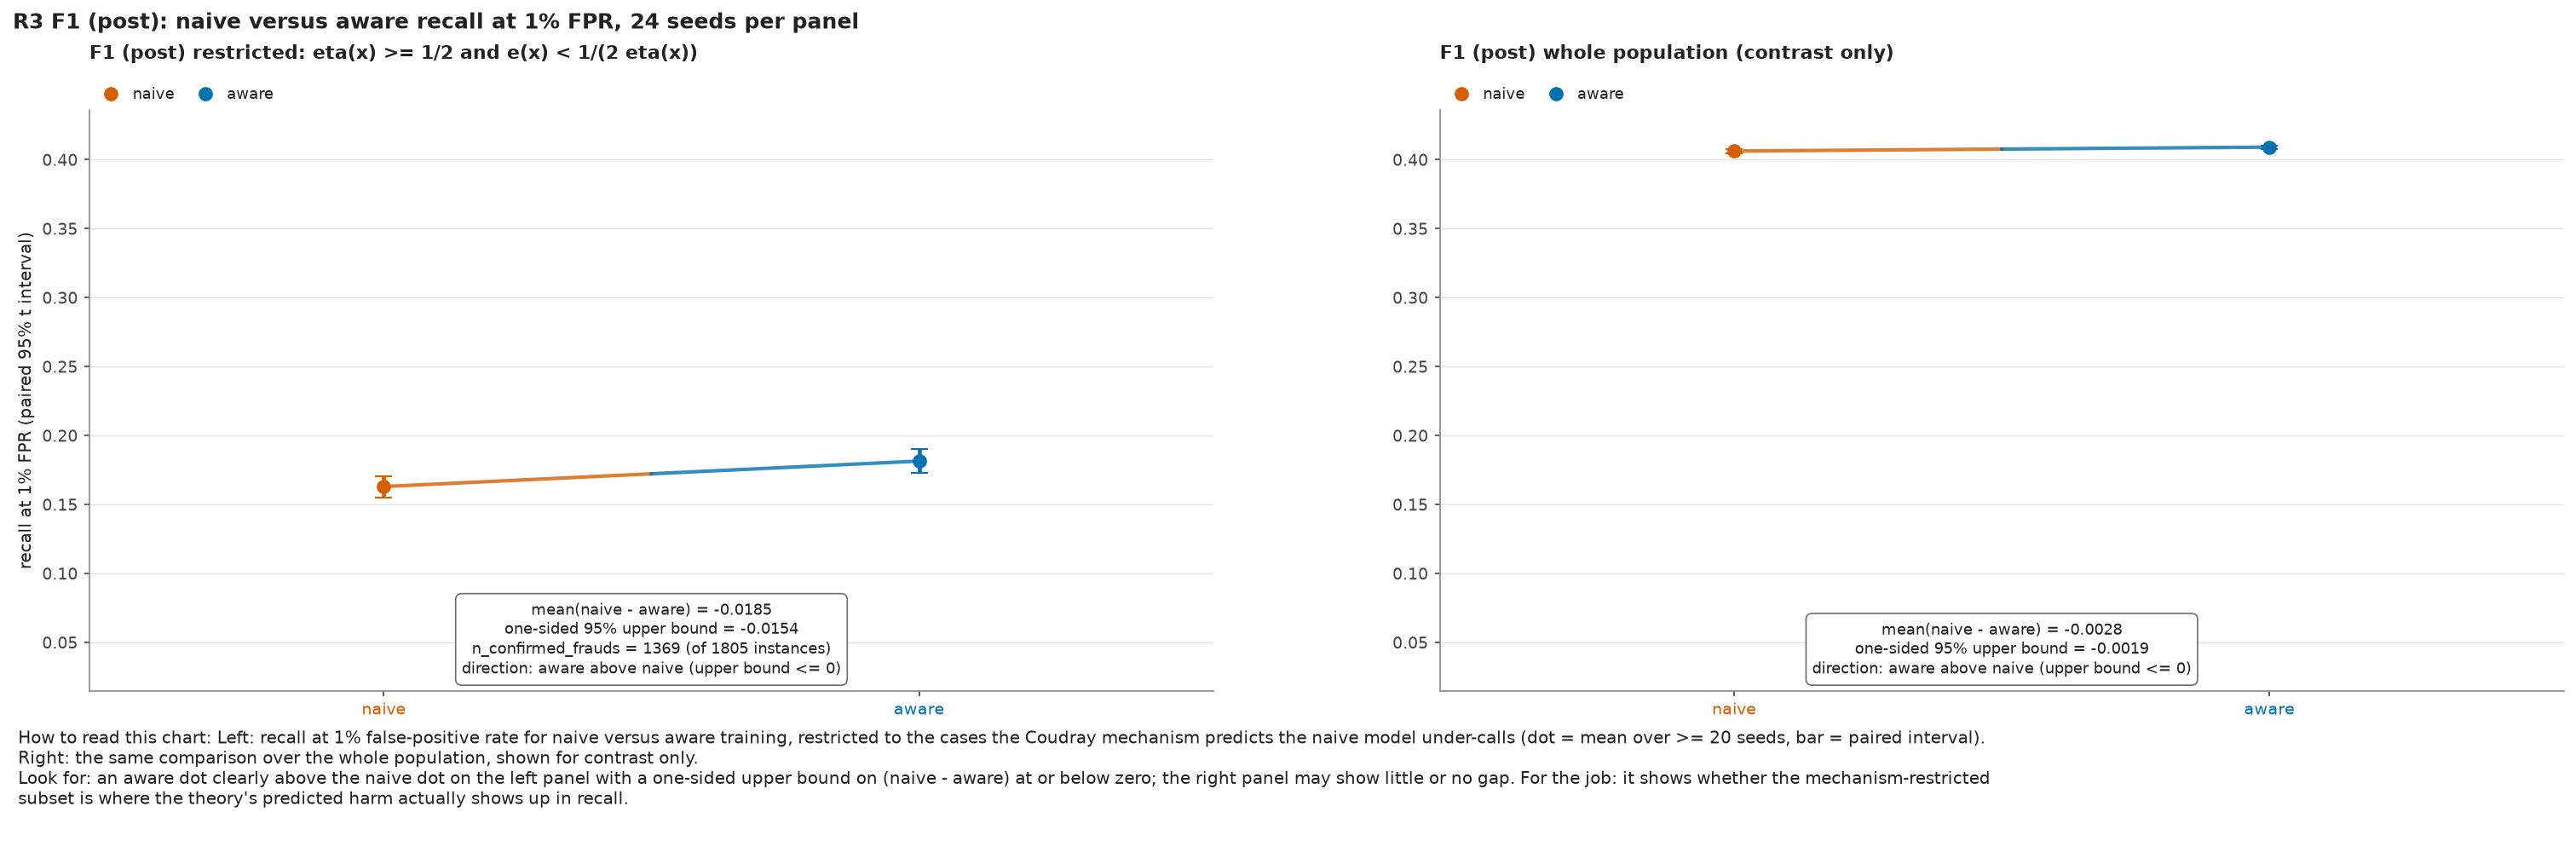

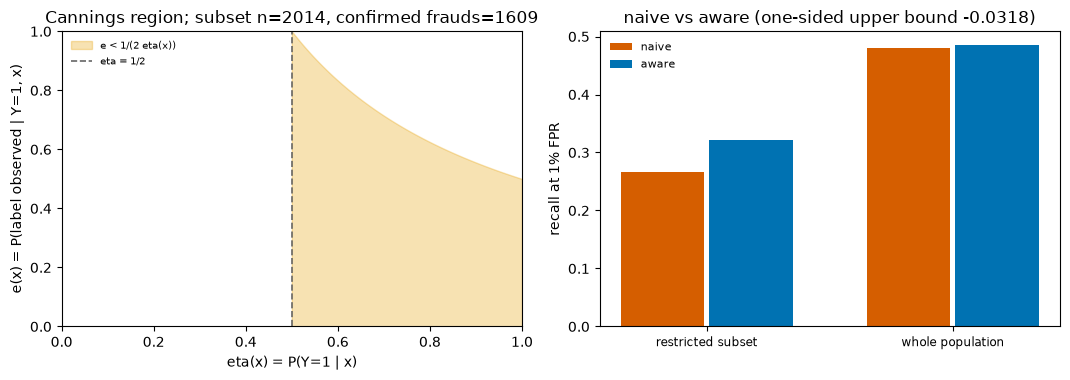

In [31]:
grid_eta = np.linspace(0.5, 1.0, 120)
fig, axes = plt.subplots(1, 2, figsize=(10.8, 3.9))
axes[0].fill_between(grid_eta, 0.0, 1.0 / (2.0 * grid_eta), color="#E69F00", alpha=0.30, label="e < 1/(2 eta(x))")
axes[0].axvline(0.5, color="#666666", ls="--", lw=1.2, label="eta = 1/2")
axes[0].set(
    xlabel="eta(x) = P(Y=1 | x)",
    ylabel="e(x) = P(label observed | Y=1, x)",
    xlim=(0.0, 1.0),
    ylim=(0.0, 1.0),
    title=f"Cannings region; subset n={subset['n_instances']}, confirmed frauds={subset['n_confirmed_frauds']}",
)
axes[0].legend(fontsize=7.5, frameon=False, loc="upper left")
positions = np.arange(2)
naive_means = [
    float(np.mean([r["naive_recall_at_1pct_fpr"] for r in subset["per_seed"]])),
    float(np.mean([r["naive_recall_at_1pct_fpr"] for r in whole["per_seed"]])),
]
aware_means = [
    float(np.mean([r["aware_recall_at_1pct_fpr"] for r in subset["per_seed"]])),
    float(np.mean([r["aware_recall_at_1pct_fpr"] for r in whole["per_seed"]])),
]
axes[1].bar(positions - 0.18, naive_means, width=0.34, color="#D55E00", label="naive")
axes[1].bar(positions + 0.18, aware_means, width=0.34, color="#0072B2", label="aware")
axes[1].set_xticks(positions, ["restricted subset", "whole population"], fontsize=8.5)
axes[1].set(ylabel="recall at 1% FPR", title=f"naive vs aware (one-sided upper bound {subset_upper:+.4f})")
axes[1].legend(fontsize=8, frameon=False)
fig.tight_layout()
r3_f1 = ROOT / "exec" / "figures" / "R3_naive_vs_aware_restricted.png"
if r3_f1.exists():
    display(Image(filename=str(r3_f1)))
else:
    plt.show()

## The naive target on an (eta, e) grid — derived here

**derived here.** The two decision rules are pure functions of `(eta(x), e(x))`: the population-optimal rule is `1{eta(x) >= 1/2}` and the naive observed-label rule is `1{e(x) eta(x) >= 1/2}`. This section evaluates both on a grid and checks that their disagreement set is *exactly* the Cannings region — the algebra behind C24, independent of any simulation.

In [32]:
eta_grid = np.linspace(0.0, 1.0, 201)
e_grid = np.linspace(0.02, 1.0, 201)
ETA, E = np.meshgrid(eta_grid, e_grid)
target_true = (ETA >= 0.5).astype(float)
target_naive = ((E * ETA) >= 0.5).astype(float)
disagreement = target_true != target_naive
cannings_region = (ETA >= 0.5) & (E < 1.0 / (2.0 * np.maximum(ETA, 1e-9)))
agreement = float(np.all(disagreement == cannings_region))
print(f"grid cells: {disagreement.size}; disagreement cells: {int(disagreement.sum())}; region cells: {int(cannings_region.sum())}")
exp.self_check(23, "grid disagreement set equals the Cannings region", agreement, 1.0, rule="ge")
exp.self_check(24, "disagreement is confined to eta >= 1/2", float(np.mean(disagreement[ETA < 0.5])), 0.0, rule="le")

grid cells: 40401; disagreement cells: 13932; region cells: 13932
SELF-CHECK 23: grid disagreement set equals the Cannings region ... PASS value=1 >= threshold=1
SELF-CHECK 24: disagreement is confined to eta >= 1/2 ... PASS value=0 <= threshold=0


True

## How to read this chart

Two heat maps over the (eta, e) plane: left is the truth rule `1{eta >= 1/2}`, middle is the naive observed-label rule `1{e eta >= 1/2}`, and right is a binary map of where they disagree. The x axis is eta(x), the y axis is e(x); colour 0/1 means "predict negative/positive".

Look for: the two rules agreeing everywhere except the lower-right wedge (eta >= 1/2 with small e), where the naive rule predicts negative. For the job: it is the exact algebraic statement of the label-selection harm — no simulation, no tuning — and it tells you which slice of the book a naive model will systematically under-call.

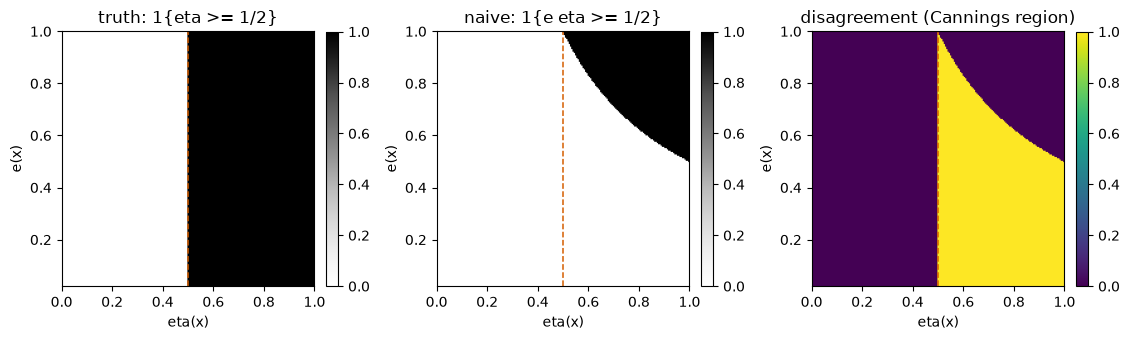

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.5))
panels = [
    (target_true, "truth: 1{eta >= 1/2}", "Greys"),
    (target_naive, "naive: 1{e eta >= 1/2}", "Greys"),
    (disagreement.astype(float), "disagreement (Cannings region)", "viridis"),
]
for axis, (values, title, cmap) in zip(axes, panels):
    image = axis.imshow(values, origin="lower", aspect="auto", extent=(0.0, 1.0, 0.02, 1.0), cmap=cmap, vmin=0.0, vmax=1.0)
    axis.axvline(0.5, color="#D55E00", ls="--", lw=1.1)
    axis.set(xlabel="eta(x)", ylabel="e(x)", title=title)
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## BASL past its first early stop — pursued, not assumed

> "E_j = (1/j) sum_{i<=j} M(f,H_i,tau)"; "while (j <= j_max) and (Delta >= eps)"

Kozodoi, Algorithm 1 (trace `fraud-labels-r1-q9`; the paper's `Delta` is signed, per `research/verification-r2.md` row K-1). Round 2 reported a single BASL iteration; **derived here** we now exercise it past that stop by raising `j_max`, and record why the criterion still stops.

In [34]:
basl_stream = exp.cached(
    "r2.reject_stream.demo",
    lambda: evaluation.generate_reject_inference_stream({**DEMO, "n_applicants": 900, "n_holdout": 800}),
)
basl_base = {**DEMO, "tolerance": 1e-6, "min_draws": 20, "max_draws": 60}
basl_j1 = exp.cached("r3.basl.j1", lambda: evaluation.run_basl(basl_stream, {**basl_base, "j_max": 1}))
basl_j6 = exp.cached("r3.basl.j6", lambda: evaluation.run_basl(basl_stream, {**basl_base, "j_max": 6}))
basl_traj = [float(value) for value in basl_j6["metric_by_iteration"]]
print(f"j_max=1: iterations={basl_j1['iterations_run']} stop={basl_j1['stop_reason']}")
print(f"j_max=6: iterations={basl_j6['iterations_run']} stop={basl_j6['stop_reason']} metric={basl_j6['early_stop_metric']} trajectory={[round(v, 6) for v in basl_traj]}")
print("labelling stage:", basl_j6["labeling"][0])
exp.self_check(25, "raising j_max to 6 does not add a second iteration", float(basl_j6["iterations_run"]), 1.0, rule="le", note=f"stop_reason={basl_j6['stop_reason']}")
exp.self_check(26, "iteration 1 does not improve the early-stop metric", basl_traj[1], basl_traj[0], rule="le", note=f"{basl_traj[0]:.6f} -> {basl_traj[1]:.6f} ({basl_j6['early_stop_metric']})")

j_max=1: iterations=1 stop=j_max
j_max=6: iterations=1 stop=no_improvement metric=auc trajectory=[0.642385, 0.642051]
labelling stage: {'n_bad': 13, 'n_filtered': 798, 'n_good': 6, 'n_sampled': 638}
SELF-CHECK 25: raising j_max to 6 does not add a second iteration ... PASS value=1 <= threshold=1 stop_reason=no_improvement
SELF-CHECK 26: iteration 1 does not improve the early-stop metric ... PASS value=0.642051 <= threshold=0.642385 0.642385 -> 0.642051 (auc)


True

## How to read this chart

Bars are the early-stop metric by iteration for the same reject-inference stream: iteration 0 is the accepts-only strong model, iteration 1 is the same model refitted after the first BASL labelling round. The dashed line marks the iteration-0 value, and the printed labels give the stop reason for `j_max=1` and `j_max=6`.

Look for: iteration 1 sitting at or below iteration 0 — that is why the paper's signed-`Delta` criterion stops after one round, and raising `j_max` alone cannot change it. For the job: it shows the difference between a stopping rule that is working and a loop that was never entered; here the rule is working and the pseudo-labelled reject budget is simply too small to move the metric.

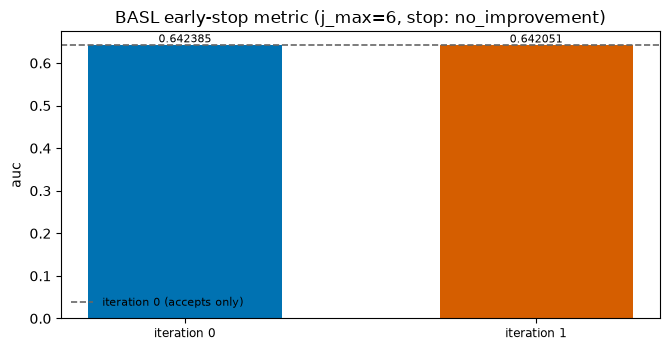

In [35]:
fig, ax = plt.subplots(figsize=(6.8, 3.6))
positions = np.arange(len(basl_traj))
ax.bar(positions, basl_traj, color=["#0072B2", "#D55E00"][: len(basl_traj)], width=0.55)
ax.axhline(basl_traj[0], color="#666666", ls="--", lw=1.2, label="iteration 0 (accepts only)")
for position, value in zip(positions, basl_traj):
    ax.text(position, value, f"{value:.6f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(positions, [f"iteration {index}" for index in positions], fontsize=8.5)
ax.set(ylabel=basl_j6["early_stop_metric"], title=f"BASL early-stop metric (j_max=6, stop: {basl_j6['stop_reason']})")
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

## What this notebook is — and is not

* **What it is:** a **synthetic**, seeded, numerical reading of three papers — the SAR loss and its
  selection correction (Coudray), Algorithm 1 with a non-oracle prior and BASL's stop rule (Kozodoi), and the
  WCTM betting/validity chain (Prinster, corrected version as ingested). Every section names its trace slug,
  every check prints its own verdict, and nothing here is a production result.
* **What it is not:** not an experiment from the papers (Coudray has none), not a frozen numeric `kappa_1`,
  not a claim that an estimated propensity inherits Eq. 13, and not a statement about real customer data.
* **Where the human extends it:** swap the demo config for `exec.config.canonical_r2_config()`, add a real
  feature pipeline behind the same `SAR` weights, and re-run the ratio grid on a wider `n` and `e_m` lattice
  before quoting any constant.